In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

[[0.97229004 0.09539795 0.02420044]
 [0.02450562 0.74230957 0.12567139]
 [0.00320435 0.16229248 0.85012817]]


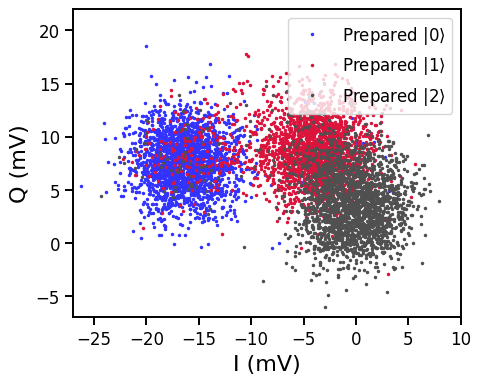

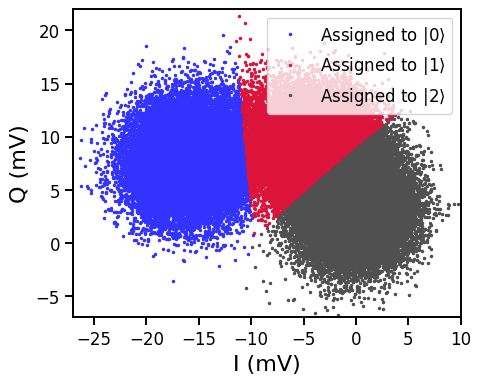

In [2]:
dark_blue = [51/255,51/255,255/255] #[65,105,225]/255; %royal blue
crimson = [220/255, 20/255, 60/255] 
dark_gray = [80/255, 80/255, 80/255] #[64/255, 64/255, 64/255]
color_list = [dark_blue, crimson, dark_gray]

single_shot_i_voltage_vs_state_and_rep = np.genfromtxt('single_shot_i_voltage_vs_state_and_rep.csv', delimiter=',')
single_shot_q_voltage_vs_state_and_rep = np.genfromtxt('single_shot_q_voltage_vs_state_and_rep.csv', delimiter=',')
assigned_states_for_each_shot = np.genfromtxt('assigned_states_for_each_shot.csv', delimiter=',')
state_assignment_mat = np.genfromtxt('state_assignment_mat.csv', delimiter=',')

print(state_assignment_mat)

N_states, N_reps = np.shape(single_shot_i_voltage_vs_state_and_rep)

# Single-shot readout voltage when preparing qubit either in g, e, or f state
fig, ax = plt.subplots(1, 1, figsize=(5,4))
ymin = -7e-3
ymax = 22e-3
xmin = -27e-3
xmax = 10e-3
for i_state in range(3):
    N_sub = 15 #sub sample for illustration purposes
    sub_samp_idx = [idx for idx in range(N_reps) if idx%N_sub == 0]
    plt.plot(1e3*single_shot_i_voltage_vs_state_and_rep[i_state, sub_samp_idx], 
             1e3*single_shot_q_voltage_vs_state_and_rep[i_state, sub_samp_idx], 
             '.', color=color_list[i_state],
             markersize=3, label = r'Prepared $|%d\rangle$'%(i_state), rasterized=True)

plt.xlabel('I (mV)', fontsize = 16)
#plt.ylabel(r'Gate error ($\times 10^{-4}$)', fontsize = 16)
plt.ylabel(r'Q (mV)', fontsize = 16)
plt.legend(fontsize = 12, loc = 'upper right') #'upper right')
#plt.title('Duration without delay: %.2f ns'%(tg_without_pad_no_pred*1e9), fontsize=14)
#plt.ylim([0.25, 1.15])
plt.ylim([ymin*1e3, ymax*1e3])
plt.xlim([xmin*1e3, xmax*1e3])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.tick_params(length=6, width = 1.4)
for side in ['top', 'left', 'right', 'bottom']:
    ax.spines[side].set_linewidth(1.4)
    
# Assigned state of each shot based on the classifier
fig, ax = plt.subplots(1, 1, figsize=(5,4))
ymin = -7e-3
ymax = 22e-3
xmin = -27e-3
xmax = 10e-3
for assigned_state in range(3):
    for prepared_state in range(3):            
        indices_assigned_to_cur_state = [idx for idx in range(N_reps) if assigned_states_for_each_shot[prepared_state, idx] == assigned_state]
        if prepared_state == 0:
            plt.plot(1e3*single_shot_i_voltage_vs_state_and_rep[prepared_state, indices_assigned_to_cur_state], 
                 1e3*single_shot_q_voltage_vs_state_and_rep[prepared_state, indices_assigned_to_cur_state], 
                 '.', color=color_list[assigned_state],
                 markersize=3, label = r'Assigned to $|%d\rangle$'%(assigned_state))
        else: 
            plt.plot(1e3*single_shot_i_voltage_vs_state_and_rep[prepared_state, indices_assigned_to_cur_state], 
                 1e3*single_shot_q_voltage_vs_state_and_rep[prepared_state, indices_assigned_to_cur_state], 
                 '.', color=color_list[assigned_state],
                 markersize=3)

plt.xlabel('I (mV)', fontsize = 16)
#plt.ylabel(r'Gate error ($\times 10^{-4}$)', fontsize = 16)
plt.ylabel(r'Q (mV)', fontsize = 16)
plt.legend(fontsize = 12, loc = 'upper right') #'upper right')
#plt.title('Duration without delay: %.2f ns'%(tg_without_pad_no_pred*1e9), fontsize=14)
#plt.ylim([0.25, 1.15])
plt.ylim([ymin*1e3, ymax*1e3])
plt.xlim([xmin*1e3, xmax*1e3])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.tick_params(length=6, width = 1.4)
for side in ['top', 'left', 'right', 'bottom']:
    ax.spines[side].set_linewidth(1.4)